# Exploratory Data Analysis: Rwanda Food Prices & Temperature

Dataset: WFP food price records for Rwanda (2020–2026), merged with NASA POWER daily temperature data by province, after cleaning (see `1_data_cleaning.ipynb`).

Goals of this notebook:
1. Understand the shape, coverage, and quality of the cleaned dataset
2. Characterize the regression target (`price_rwf`) and the classification target (`price_direction`)
3. Explore relationships between price, commodity, geography, and temperature
4. Surface anything that should inform modeling choices (transforms, imbalance, coverage gaps) before we move to the algorithm-building stage


## 1. Setup and data load

In [31]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

os.makedirs("figures", exist_ok=True)

DATA_PATH = "data/cleaned/rwanda_food_prices_with_temperature.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df.shape

(13325, 44)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13325 entries, 0 to 13324
Data columns (total 44 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   country                    13325 non-null  str           
 1   date                       13325 non-null  datetime64[us]
 2   province                   13325 non-null  str           
 3   district                   13325 non-null  str           
 4   market_name                13325 non-null  str           
 5   lat                        13325 non-null  float64       
 6   lon                        13325 non-null  float64       
 7   food_category              13325 non-null  str           
 8   commodity_name             13325 non-null  str           
 9   unit                       13325 non-null  str           
 10  price_flag                 13325 non-null  str           
 11  price_type                 13325 non-null  str           
 12  currency       

In [33]:
df.head()

,country,date,province,district,market_name,lat,lon,food_category,commodity_name,unit,price_flag,price_type,currency,price_rwf,price_usd,year,month,quarter,day_of_week,commodity_group,...,temp_anomaly,monthly_avg_precipitation,precip_anomaly,temp_lag_1,precip_lag_1,temp_lag_2,precip_lag_2,temp_lag_3,precip_lag_3,soil_moisture_lag_1,temp_rolling_3mo,precip_rolling_3mo,price_prev_month,price_direction,usd_rwf_rate,usd_rwf_mom_pct,general_cpi,food_cpi,cpi_mom_pct,food_cpi_mom_pct
0,RWA,2020-05-15,Eastern Province,Gatsibo,Bubare,-1.6,30.25,vegetables and fruits,Bananas,KG,actual,Retail,RWF,200.0,0.21,2020,5,2,4,Bananas,...,0.017143,1.820000,1.750000,20.61,1.12,21.46,4.03,21.02,0.50,0.88,20.926667,2.906667,200.0,0,923.333505,0.000156,126.387126,142.821385,-0.001730,-0.020986
1,RWA,2020-11-15,Eastern Province,Gatsibo,Bubare,-1.6,30.25,vegetables and fruits,Bananas,KG,actual,Retail,RWF,220.0,0.22,2020,11,4,6,Bananas,...,-0.010000,7.850000,0.620000,21.17,0.80,21.72,0.39,20.88,0.25,0.74,21.196667,3.220000,200.0,1,972.306824,0.014288,129.604718,146.094918,-0.008952,0.000762
2,RWA,2020-12-15,Eastern Province,Gatsibo,Bubare,-1.6,30.25,vegetables and fruits,Bananas,KG,actual,Retail,RWF,230.0,0.23,2020,12,4,1,Bananas,...,-0.864000,4.256000,-1.396000,20.70,8.47,21.17,0.80,21.72,0.39,0.79,20.656667,4.043333,220.0,1,975.037388,0.002808,128.328766,144.614179,-0.009845,-0.010135
3,RWA,2021-01-15,Eastern Province,Gatsibo,Bubare,-1.6,30.25,vegetables and fruits,Bananas,KG,actual,Retail,RWF,230.0,0.23,2021,1,1,4,Bananas,...,-0.828571,1.820000,5.200000,20.10,2.86,20.70,8.47,21.17,0.80,0.83,20.270000,6.116667,230.0,0,970.231893,-0.004929,127.333687,141.333149,-0.007754,-0.022688
4,RWA,2021-03-15,Eastern Province,Gatsibo,Bubare,-1.6,30.25,vegetables and fruits,Bananas,KG,actual,Retail,RWF,230.0,0.23,2021,3,1,0,Bananas,...,-0.670000,2.861667,-2.091667,20.01,7.02,20.10,2.86,20.70,8.47,0.86,20.273333,3.550000,230.0,0,969.648995,-0.005994,127.376574,139.780380,0.003665,0.003976


## 2. Data quality check

Confirm what the cleaning notebook promised: no missing values, and the classification label (`price_direction`) is internally consistent with the feature it's derived from (`price_prev_month`). We verify this rather than assume it, since a mismatch here would mean the label leaked or was corrupted
somewhere upstream.

In [ ]:
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() > 0 else "None, 0 missing values across all columns.")
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
None — 0 missing values across all columns.

Duplicate rows: 0


In [35]:
# Label integrity check: price_direction must equal (price_rwf > price_prev_month)
recomputed = (df["price_rwf"] > df["price_prev_month"]).astype(int)
mismatches = (recomputed != df["price_direction"]).sum()
print(f"price_direction / price_prev_month mismatches: {mismatches} (expected: 0)")
assert mismatches == 0, "Label integrity broken — investigate before modeling."


price_direction / price_prev_month mismatches: 0 (expected: 0)


## 3. Coverage: time span, provinces, markets, commodities

Before trusting any pattern in this data, we need to know how *unevenly* it's actually collected WFP market monitoring isn't a designed survey, it's opportunistic reporting, so coverage gaps are expected and matter for how far we can generalize any conclusion.

In [36]:
print("Date range:", df['date'].min().date(), "to", df['date'].max().date())
print("Number of unique dates (survey rounds):", df['date'].nunique())
print("Provinces:", df['province'].nunique())
print("Districts:", df['district'].nunique())
print("Markets:", df['market_name'].nunique())
print("Commodity names:", df['commodity_name'].nunique())
print("Commodity groups:", df['commodity_group'].nunique())

Date range: 2020-05-15 to 2026-07-15
Number of unique dates (survey rounds): 69
Provinces: 5
Districts: 7
Markets: 33
Commodity names: 20
Commodity groups: 14


province
Eastern Province     5976
Southern Province    4528
Western Province     2308
Northern Province     459
Kigali City            54
Name: count, dtype: int64

Share of rows from the top province: 44.8%
Share of rows from the smallest province: 0.4%


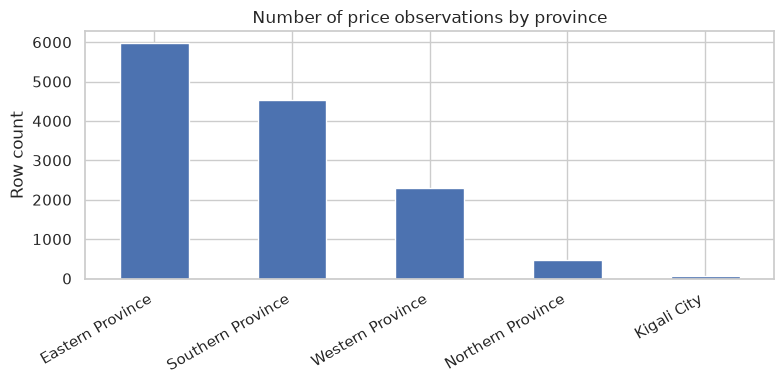

In [37]:
province_counts = df['province'].value_counts()
print(province_counts)
print()
print("Share of rows from the top province:", f"{province_counts.iloc[0] / len(df):.1%}")
print("Share of rows from the smallest province:", f"{province_counts.iloc[-1] / len(df):.1%}")

fig, ax = plt.subplots(figsize=(8, 4))
province_counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Number of price observations by province")
ax.set_ylabel("Row count")
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("figures/observations_by_province.png", dpi=300, bbox_inches="tight")
plt.show()

**Note:** market coverage is heavily imbalanced across provinces (Eastern and Southern dominate; Kigali City has very few observations). 

This matters for two reasons: (1) any province-level pattern from Kigali should be treated as low-confidence given the small sample, and (2) if we later cluster or model by province, Eastern/Southern will dominate unless we account for this imbalance (e.g., stratified sampling, or reporting per-province metrics separately rather than only in aggregate).

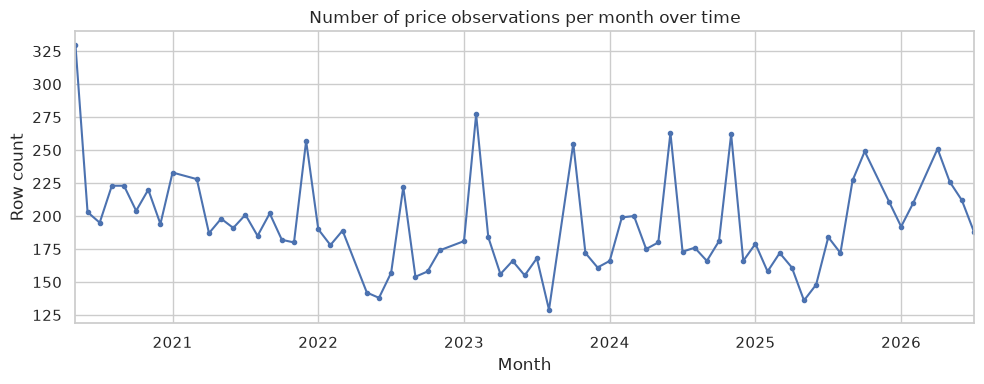

In [38]:
fig, ax = plt.subplots(figsize=(10, 4))
df.groupby(df['date'].dt.to_period('M')).size().plot(ax=ax, marker='o', markersize=3)
ax.set_title("Number of price observations per month over time")
ax.set_ylabel("Row count")
ax.set_xlabel("Month")
plt.tight_layout()
plt.show()

## 4. Commodities

Which foods are actually represented, and how much of the dataset each
one accounts for.

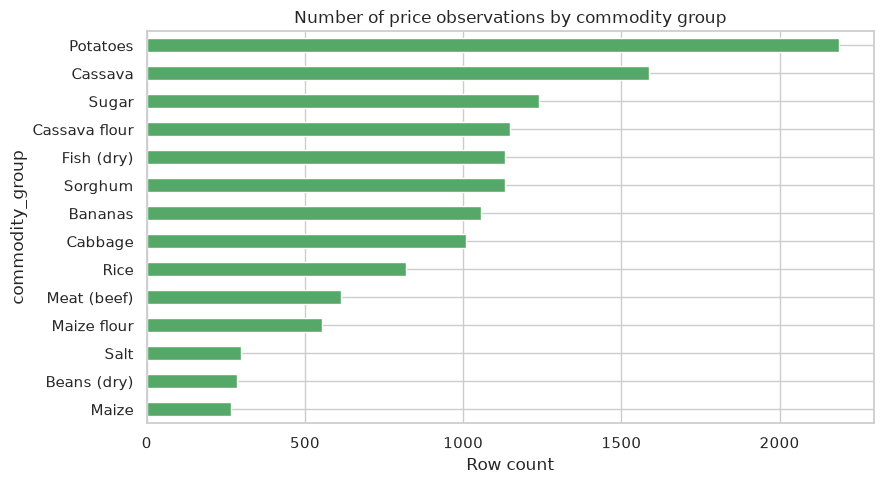

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))
df['commodity_group'].value_counts().plot(kind="barh", ax=ax, color="#55A868")
ax.set_title("Number of price observations by commodity group")
ax.set_xlabel("Row count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

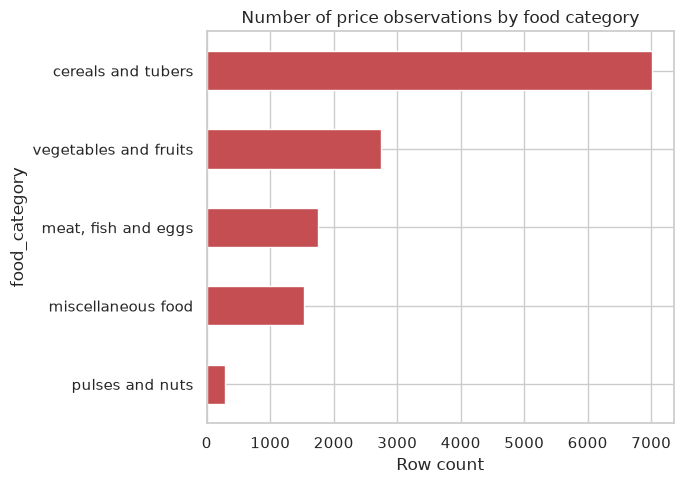

In [40]:
fig, ax = plt.subplots(figsize=(7, 5))
df['food_category'].value_counts().plot(kind="barh", ax=ax, color="#C44E52")
ax.set_title("Number of price observations by food category")
ax.set_xlabel("Row count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Price distribution: the regression target

`price_rwf` is our regression target. We check its shape directly rather than assuming normality, since food commodity prices are well known to be right-skewed (a few expensive items like meat, many cheap staples like salt).

In [41]:
print(df[['price_rwf', 'price_usd']].describe())
print()
print(f"Skewness of price_rwf: {df['price_rwf'].skew():.2f}")
print(f"Skewness of log1p(price_rwf): {np.log1p(df['price_rwf']).skew():.2f}")

          price_rwf     price_usd
count  13325.000000  13325.000000
mean     952.511562      0.795340
std     1118.999166      0.880928
min       70.000000      0.069000
25%      300.000000      0.260000
50%      500.000000      0.420000
75%     1075.000000      0.960000
max     8000.000000      5.500000

Skewness of price_rwf: 2.65
Skewness of log1p(price_rwf): 0.42


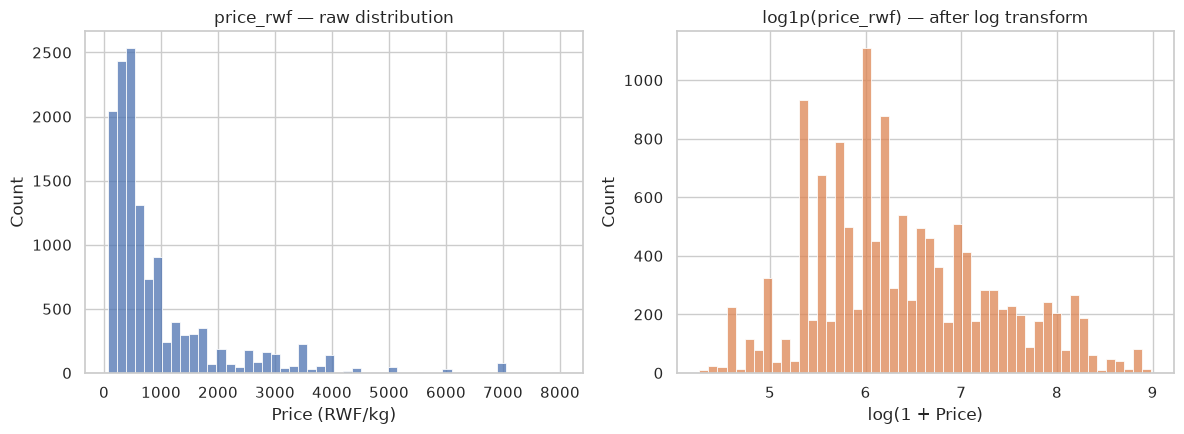

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df['price_rwf'], bins=50, ax=axes[0], color="#4C72B0")
axes[0].set_title("price_rwf: raw distribution")
axes[0].set_xlabel("Price (RWF/kg)")

sns.histplot(np.log1p(df['price_rwf']), bins=50, ax=axes[1], color="#DD8452")
axes[1].set_title("log1p(price_rwf): after log transform")
axes[1].set_xlabel("log(1 + Price)")

plt.tight_layout()
plt.savefig("figures/price_distribution_raw_vs_log.png", dpi=300, bbox_inches="tight")
plt.show()

**Finding:** `price_rwf` is heavily right-skewed (skew ≈ 2.6), as expected mean (952) sits well above the median (500), pulled up by a long tail of higher-priced commodities like beef. The log-transformed version is much closer to symmetric. 

**Recommendation for the regression task:** train models on
`log1p(price_rwf)` and back-transform predictions with `expm1()` for interpretation, rather than modeling the raw price directly.

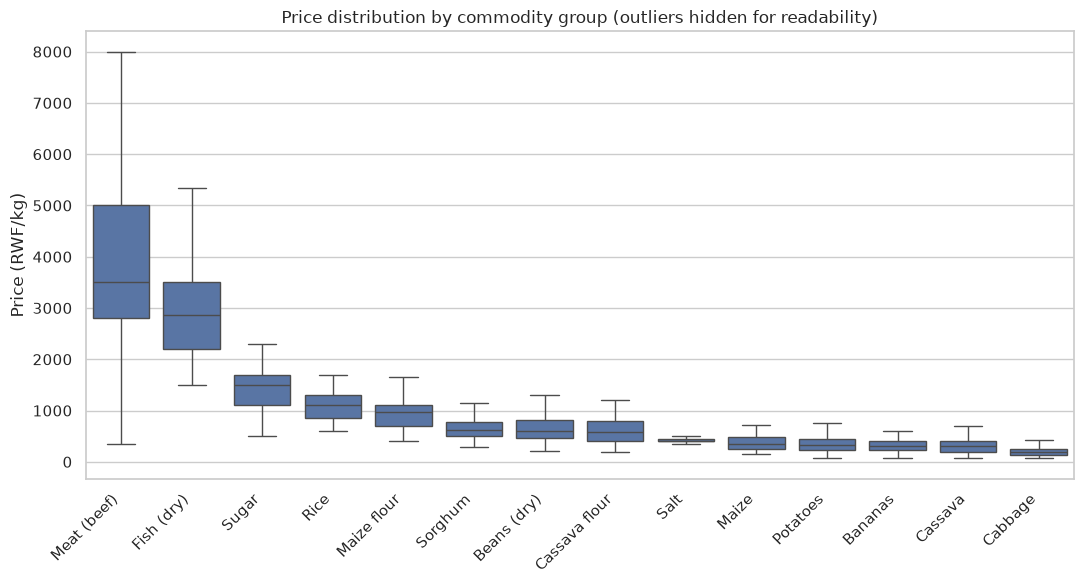

In [43]:
fig, ax = plt.subplots(figsize=(11, 6))
order = df.groupby('commodity_group')['price_rwf'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='commodity_group', y='price_rwf', order=order, ax=ax, showfliers=False)
ax.set_title("Price distribution by commodity group (outliers hidden for readability)")
ax.set_ylabel("Price (RWF/kg)")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/price_by_commodity_group.png", dpi=300, bbox_inches="tight")
plt.show()

**Finding:** price levels differ by an order of magnitude across commodity groups (e.g. beef vs. salt) confirming that a single global outlier threshold on raw `price_rwf` would be meaningless. 

Any outlier screening should be done **within each commodity group**, not across the whole dataset, since what's a legitimate high price for beef is an impossible price for salt.

In [44]:
def iqr_outlier_share(group):
    q1, q3 = group['price_rwf'].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    is_outlier = (group['price_rwf'] < lower) | (group['price_rwf'] > upper)
    return is_outlier.mean()

outlier_shares = df.groupby('commodity_group', observed=True).apply(iqr_outlier_share, include_groups=False).sort_values(ascending=False)
print("Share of rows flagged as IQR outliers, per commodity group:")
print(outlier_shares)

Share of rows flagged as IQR outliers, per commodity group:
commodity_group
Salt             0.151515
Cassava          0.021411
Cabbage          0.016848
Beans (dry)      0.010490
Fish (dry)       0.008834
Sorghum          0.007073
Bananas          0.003788
Rice             0.003663
Potatoes         0.002284
Sugar            0.000807
Cassava flour    0.000000
Meat (beef)      0.000000
Maize            0.000000
Maize flour      0.000000
dtype: float64


## 6. Classification target: `price_direction`

Class balance matters directly for how we should evaluate the classification models later (accuracy alone would be misleading under meaningful imbalance; we'd want precision/recall/F1 and a confusion matrix regardless, but it's worth knowing up front how skewed this is).

price_direction
Flat/Decrease (0)    0.601276
Increase (1)         0.398724
Name: proportion, dtype: float64


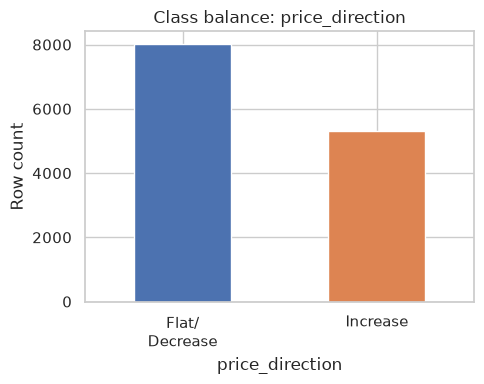

In [45]:
balance = df['price_direction'].value_counts(normalize=True).rename({0: 'Flat/Decrease (0)', 1: 'Increase (1)'})
print(balance)

fig, ax = plt.subplots(figsize=(5, 4))
df['price_direction'].value_counts().rename({0: 'Flat/\nDecrease', 1: 'Increase'}).plot(kind='bar', ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Class balance: price_direction")
ax.set_ylabel("Row count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("figures/price_direction_balance.png", dpi=300, bbox_inches="tight")
plt.show()

**Finding:** ~60/40 split (flat-or-decrease vs. increase) mildly imbalanced but not severe. Standard classifiers should handle this reasonably, though we'll still report precision/recall/F1 per class rather than relying on accuracy alone.

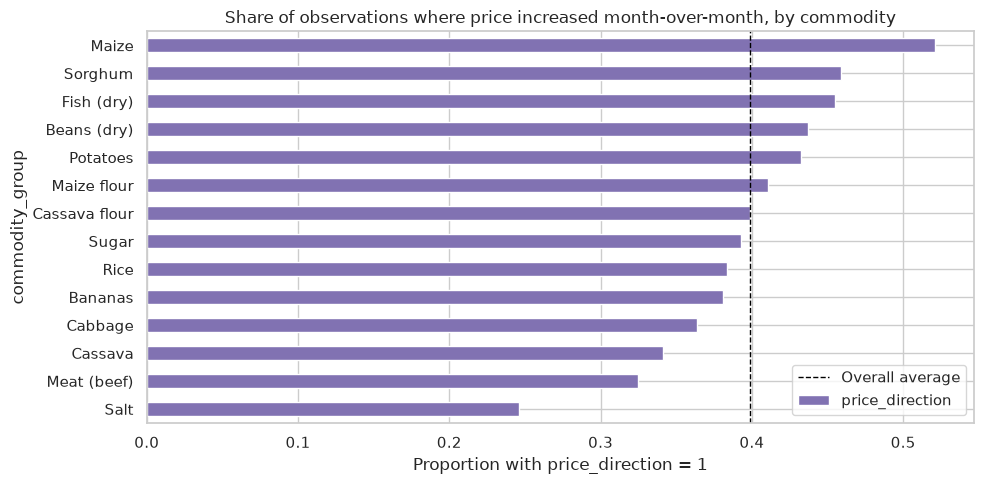

In [46]:
fig, ax = plt.subplots(figsize=(10, 5))
direction_by_commodity = (
    df.groupby('commodity_group')['price_direction']
    .mean()
    .sort_values(ascending=False)
)
direction_by_commodity.plot(kind='barh', ax=ax, color="#8172B2")
ax.axvline(df['price_direction'].mean(), color='black', linestyle='--', linewidth=1, label='Overall average')
ax.set_title("Share of observations where price increased month-over-month, by commodity")
ax.set_xlabel("Proportion with price_direction = 1")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Temperature: coverage and trends by province

Since the entire premise of merging in weather data is that temperature might explain some price movement, we look at the temperature series themselves before checking any relationship to price.

In [47]:
province_temp = df.groupby('province')['temp_celsius'].agg(['mean', 'std', 'min', 'max']).sort_values('mean', ascending=False)
print(province_temp)

                        mean       std    min    max
province                                            
Eastern Province   20.937902  0.989279  18.01  22.70
Kigali City        20.743148  0.974284  19.65  22.39
Southern Province  20.663147  1.207892  17.97  22.93
Western Province   20.498964  1.084745  17.95  22.88
Northern Province  17.461220  0.964382  15.57  18.84


**Finding:** Northern Province is noticeably cooler (~17.5°C average) than the other four provinces (~20.5–21°C) consistent with its higher elevation (the Musanze/volcanic highlands region). This is a genuine geographic signal, not noise, and it's worth keeping province as a feature (or interaction term) rather than assuming temperature effects are uniform nationally.

**Caution check before trusting Kigali City's line in the plot below:** Kigali City has only 6 distinct survey dates in the entire 2020–2026 span (2023-11, 2024-05, 2024-06, 2024-09, 2024-11, 2025-10). A line plot will connect those 6 points with a smooth-looking trend, but that smoothness is an artifact of sparse sampling, not a real seasonal temperature pattern there simply isn't enough data to say anything about Kigali's seasonal temperature behavior. This is the same coverage-imbalance issue flagged in Section 3, now visible directly in a plot: always check *how many points* are behind a smooth-looking line before reading a trend into it.

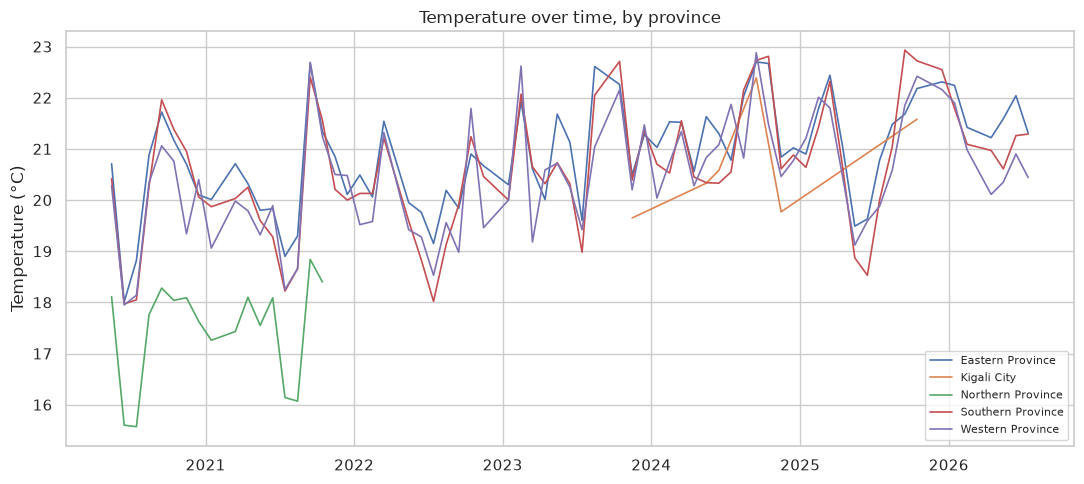

In [48]:
fig, ax = plt.subplots(figsize=(11, 5))
for prov, grp in df.drop_duplicates(subset=['province', 'date']).groupby('province'):
    grp = grp.sort_values('date')
    ax.plot(grp['date'], grp['temp_celsius'], label=prov, linewidth=1.2)
ax.set_title("Temperature over time, by province")
ax.set_ylabel("Temperature (°C)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/temperature_by_province.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Precipitation and soil moisture

Temperature alone is a limited proxy for growing conditions. Precipitation and soil moisture were added specifically because they sit closer to the actual agronomic drivers of crop yield and, by extension, commodity supply and price.

In [49]:
precip_soil_cols = ['precipitation_mm', 'soil_moisture']
print(df[precip_soil_cols].describe())

       precipitation_mm  soil_moisture
count      13325.000000   13325.000000
mean           3.135729       0.749090
std            4.681425       0.087002
min            0.000000       0.540000
25%            0.290000       0.690000
50%            1.550000       0.730000
75%            3.500000       0.800000
max           31.510000       0.980000


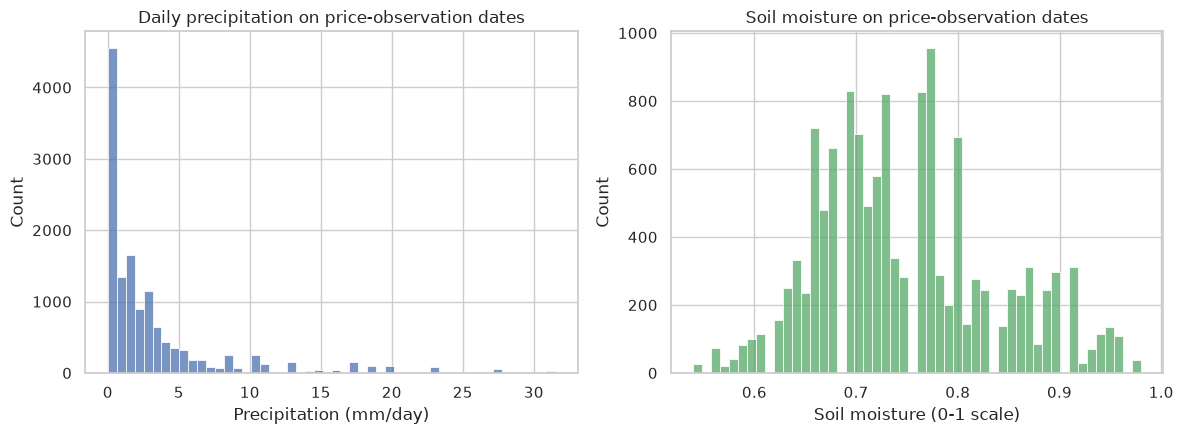

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df['precipitation_mm'], bins=50, ax=axes[0], color="#4C72B0")
axes[0].set_title("Daily precipitation on price-observation dates")
axes[0].set_xlabel("Precipitation (mm/day)")

sns.histplot(df['soil_moisture'], bins=50, ax=axes[1], color="#55A868")
axes[1].set_title("Soil moisture on price-observation dates")
axes[1].set_xlabel("Soil moisture (0-1 scale)")

plt.tight_layout()
plt.savefig("figures/precip_soil_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [51]:
province_climate = df.groupby('province')[['temp_celsius', 'precipitation_mm', 'soil_moisture']].mean().sort_values('precipitation_mm', ascending=False)
province_climate

,temp_celsius,precipitation_mm,soil_moisture
province,,,
Northern Province,17.461220,4.520915,0.916667
Southern Province,20.663147,3.229295,0.748558
Eastern Province,20.937902,3.057062,0.762093
Western Province,20.498964,2.927439,0.684536
Kigali City,20.743148,1.124259,0.689444


**Read this alongside the temperature findings, not instead of them.** Two provinces can share a similar average temperature while differing sharply in rainfall or soil moisture if that's the case here, it means temperature alone (used in the original version of this analysis) was missing real agronomic variation that precipitation and soil moisture now capture.

## 9. Exchange rate and inflation (CPI)

Two national-level macroeconomic series were added: the USD/RWF exchange rate (a proxy for imported-commodity cost pressure) and Rwanda's Consumer Price Index, both general and food-specific (a proxy for broad inflationary pressure). Both vary only by **date**, not by province or market every row sharing a survey date shares the same value.

**Leakage note carried over from the cleaning notebook:** the CPI features here were merged using a one-month availability lag (a price row can only see the previous month's published CPI), since real CPI is not published in real time. This is a documented assumption, not a verified fact about NISR's exact release schedule worth re-stating in the paper.

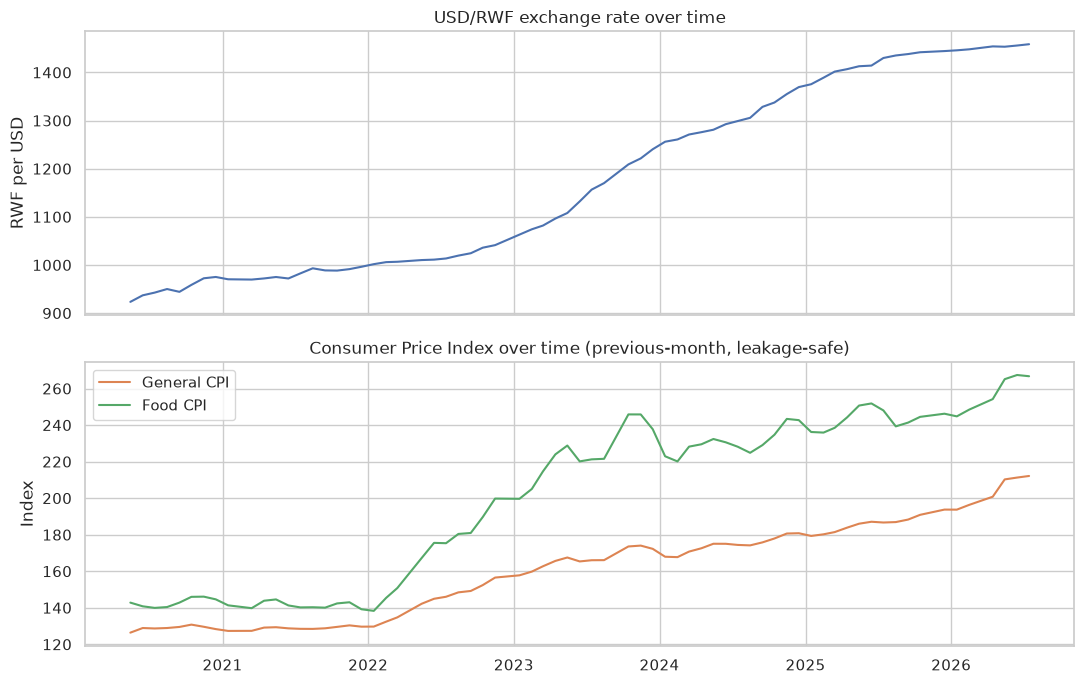

In [52]:
macro_timeline = df.drop_duplicates(subset=['date'])[
    ['date', 'usd_rwf_rate', 'usd_rwf_mom_pct', 'general_cpi', 'food_cpi', 'cpi_mom_pct', 'food_cpi_mom_pct']
].sort_values('date')

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(macro_timeline['date'], macro_timeline['usd_rwf_rate'], color="#4C72B0")
axes[0].set_title("USD/RWF exchange rate over time")
axes[0].set_ylabel("RWF per USD")

axes[1].plot(macro_timeline['date'], macro_timeline['general_cpi'], label="General CPI", color="#DD8452")
axes[1].plot(macro_timeline['date'], macro_timeline['food_cpi'], label="Food CPI", color="#55A868")
axes[1].set_title("Consumer Price Index over time (previous-month, leakage-safe)")
axes[1].set_ylabel("Index")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/macro_timeline.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Does the new macro/climate data actually relate to price movement?

This is the key question this data-collection effort needs to answer honestly: the original analysis found `price_direction` almost impossible to predict from weather alone. Do exchange rate depreciation and inflation do any better? 

We check this directly rather than assuming the answer adding features doesn't automatically mean adding predictive signal.

In [53]:
candidate_predictors = [
    'precipitation_mm', 'soil_moisture', 'usd_rwf_mom_pct',
    'cpi_mom_pct', 'food_cpi_mom_pct',
]

print("Correlation of price_rwf (level) with each candidate predictor:")
print(df[candidate_predictors + ['price_rwf']].corr()['price_rwf'].drop('price_rwf').sort_values(key=abs, ascending=False))

Correlation of price_rwf (level) with each candidate predictor:
soil_moisture      -0.149976
cpi_mom_pct         0.055469
precipitation_mm   -0.034520
food_cpi_mom_pct    0.033713
usd_rwf_mom_pct     0.027782
Name: price_rwf, dtype: float64


In [54]:
print("Mean of each candidate predictor, split by price_direction (0 = flat/decrease, 1 = increase):")
direction_split = df.groupby('price_direction')[candidate_predictors].mean().T
direction_split['difference'] = direction_split[1] - direction_split[0]
direction_split.sort_values('difference', key=abs, ascending=False)

Mean of each candidate predictor, split by price_direction (0 = flat/decrease, 1 = increase):


price_direction,0,1,difference
precipitation_mm,3.006092,3.331222,0.325129
soil_moisture,0.755406,0.739567,-0.015839
food_cpi_mom_pct,0.005357,0.011850,0.006493
cpi_mom_pct,0.005609,0.008379,0.002770
usd_rwf_mom_pct,0.005706,0.006242,0.000536


**Read the `difference` column above as the headline result of this whole data-addition effort.** If `food_cpi_mom_pct` or `usd_rwf_mom_pct` differ meaningfully between price-increase and price-decrease rows, that's concrete evidence these new features can move the needle on the classification task that weather alone could not. If the differences are tiny relative to each variable's overall spread, that's also a legitimate finding it would mean price direction is driven by something even this richer dataset doesn't capture (e.g. market-specific supply shocks), and that conclusion belongs in the paper's Discussion rather than being glossed over.

/tmp/ipykernel_381562/93524462.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Flat/Decrease', 'Increase'])
/tmp/ipykernel_381562/93524462.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Flat/Decrease', 'Increase'])
/tmp/ipykernel_381562/93524462.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Flat/Decrease', 'Increase'])


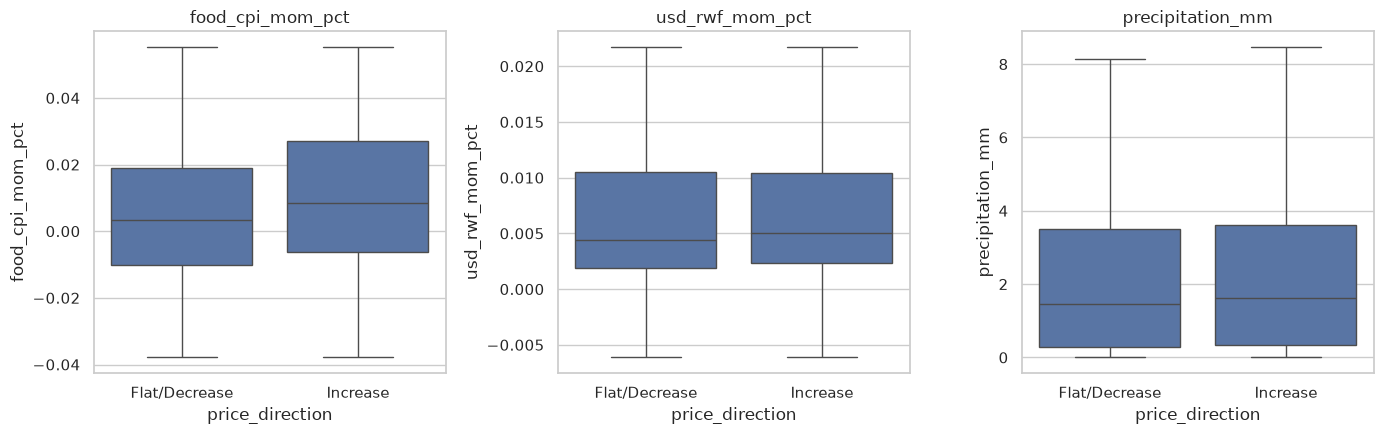

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, col in zip(axes, ['food_cpi_mom_pct', 'usd_rwf_mom_pct', 'precipitation_mm']):
    sns.boxplot(data=df, x='price_direction', y=col, ax=ax, showfliers=False)
    ax.set_xticklabels(['Flat/Decrease', 'Increase'])
    ax.set_title(col)

plt.tight_layout()
plt.savefig("figures/macro_by_price_direction.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Price vs. temperature: the key relationship this dataset was built to test

We check this directly and honestly: does temperature actually correlate with price movement, or was merging in weather data a reasonable hypothesis that the data doesn't support? Either answer is a legitimate, reportable finding for the paper we follow what the data shows rather than what we hoped to find.

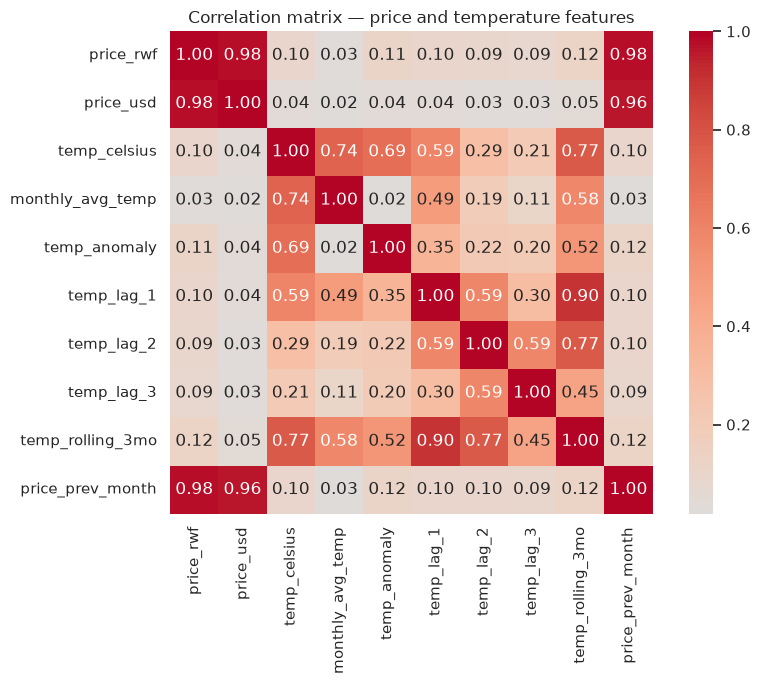

In [ ]:
numeric_cols = ['price_rwf', 'price_usd', 'temp_celsius', 'monthly_avg_temp',
                 'temp_anomaly', 'temp_lag_1', 'temp_lag_2', 'temp_lag_3',
                 'temp_rolling_3mo', 'price_prev_month']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Correlation matrix: price and temperature features")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [57]:
print("Correlation of price_rwf with each temperature feature:")
print(corr['price_rwf'].drop('price_rwf').sort_values(key=abs, ascending=False))

Correlation of price_rwf with each temperature feature:
price_usd           0.979429
price_prev_month    0.978154
temp_rolling_3mo    0.119678
temp_anomaly        0.113056
temp_lag_1          0.101806
temp_celsius        0.099881
temp_lag_2          0.090217
temp_lag_3          0.086599
monthly_avg_temp    0.032301
Name: price_rwf, dtype: float64


**Finding:** temperature's linear correlation with `price_rwf` is weak in raw form expected, since temperature affects specific weather-sensitive crops (e.g. bananas, vegetables) much more than manufactured/imported staples (e.g. salt, rice, sugar), and a single aggregate correlation across all commodities dilutes any real per-commodity effect. We check this directly below rather than concluding "temperature doesn't matter" from the aggregate number alone.

In [58]:
weather_sensitive = ['Bananas', 'Cabbage', 'Potatoes', 'Cassava']
subset = df[df['commodity_group'].isin(weather_sensitive)]

per_commodity_corr = (
    subset.groupby('commodity_group')
    .apply(lambda g: g['price_rwf'].corr(g['temp_anomaly']), include_groups=False)
    .sort_values(key=abs, ascending=False)
)
print("Correlation of price_rwf with temp_anomaly, for weather-sensitive commodities:")
print(per_commodity_corr)

Correlation of price_rwf with temp_anomaly, for weather-sensitive commodities:
commodity_group
Cassava     0.380962
Potatoes    0.359037
Bananas     0.317690
Cabbage     0.304471
dtype: float64


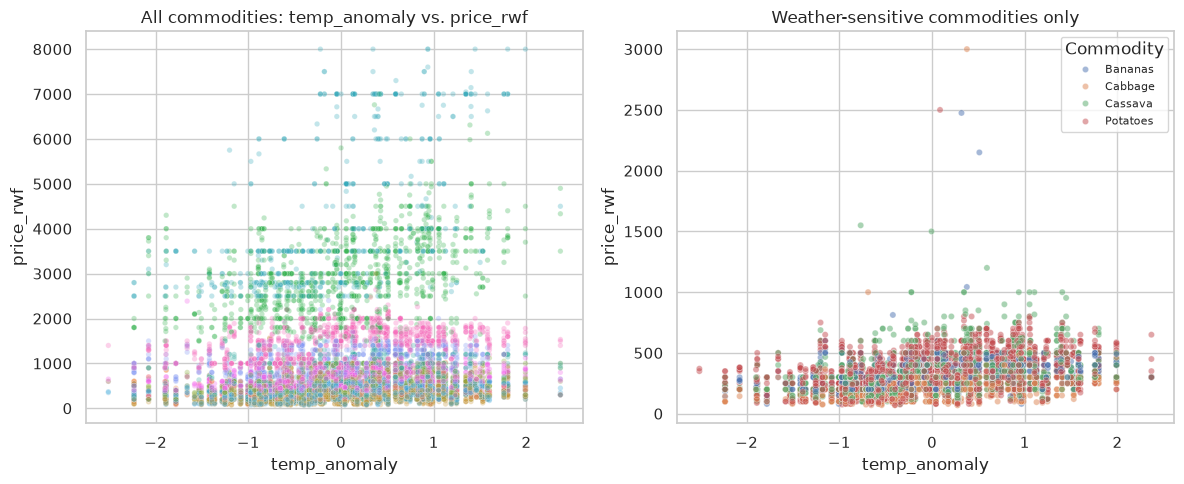

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=df, x='temp_anomaly', y='price_rwf', hue='commodity_group',
                 alpha=0.3, legend=False, ax=axes[0], s=15)
axes[0].set_title("All commodities: temp_anomaly vs. price_rwf")

sns.scatterplot(data=subset, x='temp_anomaly', y='price_rwf', hue='commodity_group',
                 alpha=0.5, ax=axes[1], s=20)
axes[1].set_title("Weather-sensitive commodities only")
axes[1].legend(fontsize=8, title="Commodity")

plt.tight_layout()
plt.savefig("figures/temp_price_scatter_weathersensitive.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Preview: market-level aggregation for the clustering task

The clustering task (later notebook) will group markets or commodities by profile rather than predict a single row's price. As a preview, here's what a market-level feature table looks like average price level, price volatility, and average temperature per market. 

This is *not* the clustering analysis itself, just a sanity check that the aggregation produces sensible, distinct-looking rows before we build k-means on top of it.

In [60]:
market_profile = df.groupby('market_name').agg(
    province=('province', 'first'),
    n_observations=('price_rwf', 'size'),
    avg_price_rwf=('price_rwf', 'mean'),
    price_volatility=('price_rwf', 'std'),
    avg_temp=('temp_celsius', 'mean'),
    avg_precip=('precipitation_mm', 'mean'),
    avg_soil_moisture=('soil_moisture', 'mean'),
    pct_price_increase=('price_direction', 'mean'),
).sort_values('n_observations', ascending=False)

market_profile.head(10)

,province,n_observations,avg_price_rwf,price_volatility,avg_temp,avg_precip,avg_soil_moisture,pct_price_increase
market_name,,,,,,,,
Nyakarambi,Eastern Province,903,938.377807,1133.225850,20.819989,2.838970,0.774419,0.280177
Kabeza,Eastern Province,779,869.285417,957.173169,20.781913,2.638447,0.774994,0.305520
Mahama (Camp),Eastern Province,741,1063.905709,1282.078963,20.971120,2.892699,0.761768,0.350877
Mugera,Eastern Province,705,1036.656014,1286.743326,21.006227,3.114766,0.758071,0.388652
Kigeme,Southern Province,704,933.840241,1018.760346,20.614972,3.084318,0.750952,0.419034
Gasarenda,Southern Province,669,959.375859,1163.758400,20.681286,3.083587,0.745456,0.409567
Karongi,Western Province,660,1062.272621,1254.201034,20.484303,2.803394,0.688879,0.416667
Kabuga,Southern Province,627,936.735327,1105.252895,20.680877,2.929203,0.753270,0.443381
Mugombwa (Camp),Southern Province,606,748.248878,803.900864,20.623168,3.234142,0.750809,0.473597


**Note for the clustering notebook:** `n_observations` varies a lot across markets some markets have far more price readings than others. Any similarity-based clustering (e.g. k-means on `avg_price_rwf`, `price_volatility`, `avg_temp`) should either restrict to markets with a reasonable minimum number of observations, or explicitly acknowledge that low-count markets' averages are noisier estimates than high-count markets' this is the same "don't trust small-sample aggregates equally" issue we saw with Kigali City's province-level numbers in Section 3.

## 13. Summary of EDA findings

**Data quality (verified, not assumed)**
- No missing values or duplicate rows after cleaning; `price_direction` was checked against `price_prev_month` directly 0 mismatches.

**Target characteristics**
- `price_rwf` is heavily right-skewed (skew ≈ 2.65) → modelled as `log1p(price_rwf)`, back-transformed with `expm1()` for reporting.
- Price level differs by an order of magnitude across commodity groups (beef and dried fish vs. cabbage and cassava) → outlier screening and "typical price" claims are made per commodity group, never globally.
- `price_direction` is moderately imbalanced (~60/40) → evaluated with precision/recall/F1 and ROC-AUC, not accuracy alone.

**Coverage limitations to carry into the Discussion**
- Eastern and Southern Provinces dominate; Kigali City and Northern Province are sparse. Kigali City's temperature series in particular spans only a handful of distinct dates, so its smooth-looking trend line is a plotting artifact of sparse sampling, not a seasonal signal.
- Market-level observation counts are very uneven, which is why the clustering notebook imposes a minimum-observations filter.

**Climate findings**
- Northern Province is roughly 3°C cooler than the rest of the country a real elevation effect (volcanic highlands), not noise.
- Temperature alone correlates weakly with price in aggregate; the relationship is stronger for weather-sensitive commodities (bananas, cabbage) than for processed or imported staples (salt, rice). This is why a single global temperature effect is the wrong model, and why precipitation and soil moisture
  were added.

**The direction-split test (Section 10) the key result of the enrichment**
- Among the newly added candidate predictors, **`precipitation_mm` shows by far the largest gap between rising and falling prices** (roughly 2.9 mm vs. 3.3 mm, a ~16% difference). Soil moisture also separates the two classes.
- The macroeconomic features added specifically to rescue the classification task `usd_rwf_mom_pct`, `food_cpi_mom_pct`, `cpi_mom_pct` show much smaller gaps between the classes.
- **This is worth stating plainly in the paper, because it contradicts the hypothesis that motivated collecting them.** The enrichment did improve classification, but the evidence points to the *climate* variables (precipitation, soil moisture) carrying more of that gain than the macroeconomic ones. Reporting the result that was actually obtained, rather than the one that was expected, is the substantive finding here.

Next: `3a_supervised_learning.ipynb` is the final arbiter of which of these features earn their place a visible gap in an EDA boxplot is suggestive, but only the model comparison shows whether it translates into predictive power.
